# Taylor Series: Approximating a Function with a Polynomial

**This notebook is self-contained; it recaps derivatives and error before combining them.**

This is the last idea in the unit, and it closes a loop opened in the first notebook.

Polynomials are the easiest functions there are — add, multiply, differentiate, all trivial. Functions
like $\sin x$, $e^x$, and $\log x$ are not: a computer cannot evaluate them directly either. So we
approximate them **by polynomials**, and the recipe for doing so is the Taylor series.

By the end we will also be able to explain something left hanging in §3.4: *why* the forward difference
has error $O(h)$ and the central difference $O(h^2)$.

## Learning objectives

- Build a **Taylor polynomial** from a function's derivatives at a point.
- Watch accuracy improve with **degree**, and degrade with **distance** from the expansion point.
- Explain the small-angle approximation $\sin x \approx x$.
- Derive §3.4's error rates.

## Background

Pick an **expansion point** $a$. The idea is to build a polynomial that matches $f$ *and all its
derivatives* at that point — same value, same slope, same concavity, and so on. The polynomial that
does it is

$$P_n(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \cdots + \frac{f^{(n)}(a)}{n!}(x-a)^n$$

Each term uses one more derivative and pins down one more feature of the shape. Around $a = 0$ the
familiar cases are

$$\sin x \approx x - \frac{x^3}{3!} + \frac{x^5}{5!} - \cdots, \qquad
  e^x \approx 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots$$

Truncating after the first term of $\sin$ gives the **small-angle approximation** $\sin x \approx x$,
which is exactly the kind of estimate §3.1 measured the error of without saying where it came from.

Two properties matter, and both are visible in the plots below: accuracy **improves with degree**, and
**degrades with distance** from $a$. A Taylor polynomial is a *local* approximation.

## This notebook covers

1. Building the polynomial, one term at a time.
2. More terms: closing in on the curve.
3. The small-angle approximation.
4. Error versus degree, and versus distance.
5. Where §3.4's $O(h)$ and $O(h^2)$ came from.

**Prerequisites:** `U3-3_Derivatives-2_Rules`, `U3-4_NumericalDerivatives-1_FiniteDifference`, `U3-1_Approximation-1_ModelsAndError`

**Dataset:** none — known functions, so the exact error is available.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from math import factorial
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## 1. One term at a time

Expand $f(x) = \sin(x)$ about $a = 0$. Its derivatives cycle with period four —
$\sin, \cos, -\sin, -\cos$ — so at $a = 0$ they are $0, 1, 0, -1, 0, 1, \dots$ and the polynomial
keeps only the odd powers.

**A note on how we get the derivatives.** We use the closed forms, because differencing repeatedly to
get a high-order derivative is numerically unreliable — section 5 measures exactly how unreliable, and
ties it back to §3.4.

In [2]:
def f(x):
    return np.sin(x)

def nth_derivative_exact(k, a):
    # derivatives of sin cycle every 4: sin, cos, -sin, -cos
    return [np.sin, np.cos, lambda t: -np.sin(t), lambda t: -np.cos(t)][k % 4](a)

def taylor(x, a, n):
    total = np.zeros_like(np.asarray(x, dtype=float))
    for k in range(n + 1):
        total = total + nth_derivative_exact(k, a) * (x - a)**k / factorial(k)
    return total

a = 0.0
print("derivatives of sin(x) at x = 0:")
for k in range(6):
    print(f"   f^({k})(0) = {nth_derivative_exact(k, a):+.0f}")
print("\nso the polynomial is  x - x^3/3! + x^5/5! - ...   (only odd powers survive)")

derivatives of sin(x) at x = 0:
   f^(0)(0) = +0
   f^(1)(0) = +1
   f^(2)(0) = -0
   f^(3)(0) = -1
   f^(4)(0) = +0
   f^(5)(0) = +1

so the polynomial is  x - x^3/3! + x^5/5! - ...   (only odd powers survive)


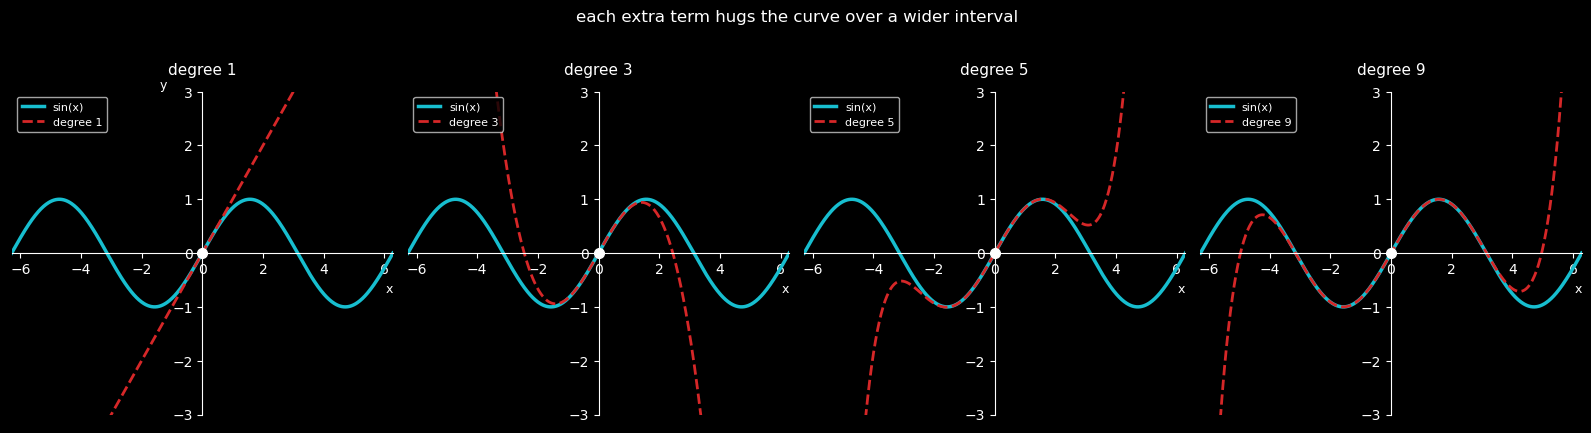

In [3]:
xs = np.linspace(-2*np.pi, 2*np.pi, 600)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, n in zip(axes, [1, 3, 5, 9]):
    ax.plot(xs, f(xs), color="tab:cyan", lw=2.5, label="sin(x)")
    ax.plot(xs, taylor(xs, a, n), "--", color="tab:red", lw=2, label=f"degree {n}")
    ax.plot(a, f(a), "o", color="white", markersize=7, zorder=5)
    center_axes(ax)
    ax.set_ylim(-3, 3); ax.set_xlim(-2*np.pi, 2*np.pi)
    ax.set_xlabel("x", loc="right", fontsize=9)
    ax.set_title(f"degree {n}", pad=12, fontsize=11)
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("y", loc="top", rotation=0, fontsize=9)
plt.suptitle("each extra term hugs the curve over a wider interval", y=1.02)
plt.tight_layout()
plt.show()

Watch the interval of good agreement **widen** with each panel. Degree 1 is only right very near the
origin; degree 9 tracks $\sin$ across more than a full period before peeling away.

## 2. Building up, animated

The same progression as an animation over **degree**. Each frame adds one more term.

*(Press play. The animation code is mechanics.)*

In [4]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=80)
ax.plot(xs, f(xs), color="tab:cyan", lw=2.5)
approx_line, = ax.plot([], [], "--", color="tab:red", lw=2)
center_axes(ax)
ax.set_xlim(-2*np.pi, 2*np.pi); ax.set_ylim(-3, 3)
ax.set_xlabel("x", loc="right")
title = ax.set_title("")

degrees = list(range(0, 16))

def animate(i):
    n = degrees[i]
    approx_line.set_data(xs, taylor(xs, a, n))
    title.set_text(f"Taylor polynomial of degree {n}")
    return approx_line, title

ani = FuncAnimation(fig, animate, frames=len(degrees), interval=600, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())

## 3. The small-angle approximation

Keep only the first term of $\sin$'s expansion and you get the single most-used approximation in
physics and engineering:

$$\sin x \approx x \quad \text{for small } x$$

It is why a pendulum's equation is solvable, and it is where §3.1's $\sin(\pi/8) \approx 3/8$
ultimately comes from — $\pi/8 \approx 0.3927$, and rounding that to the convenient fraction $3/8$
gives $0.375$.

Below, exactly how small "small" has to be for a chosen tolerance.

In [5]:
print(f"{'x':>8} {'sin(x)':>12} {'x':>12} {'rel error':>12}")
print("-" * 48)
for xv in [0.01, 0.05, 0.1, 0.2, 0.3927, 0.5, 1.0]:
    s = math.sin(xv)
    rel = abs(xv - s) / abs(s)
    note = "   <- pi/8, the section 3.1 example" if abs(xv - np.pi/8) < 1e-3 else ""
    print(f"{xv:8.4f} {s:12.6f} {xv:12.6f} {rel*100:11.3f}%{note}")

       x       sin(x)            x    rel error
------------------------------------------------
  0.0100     0.010000     0.010000       0.002%
  0.0500     0.049979     0.050000       0.042%
  0.1000     0.099833     0.100000       0.167%
  0.2000     0.198669     0.200000       0.670%
  0.3927     0.382684     0.392700       2.617%   <- pi/8, the section 3.1 example
  0.5000     0.479426     0.500000       4.291%
  1.0000     0.841471     1.000000      18.840%


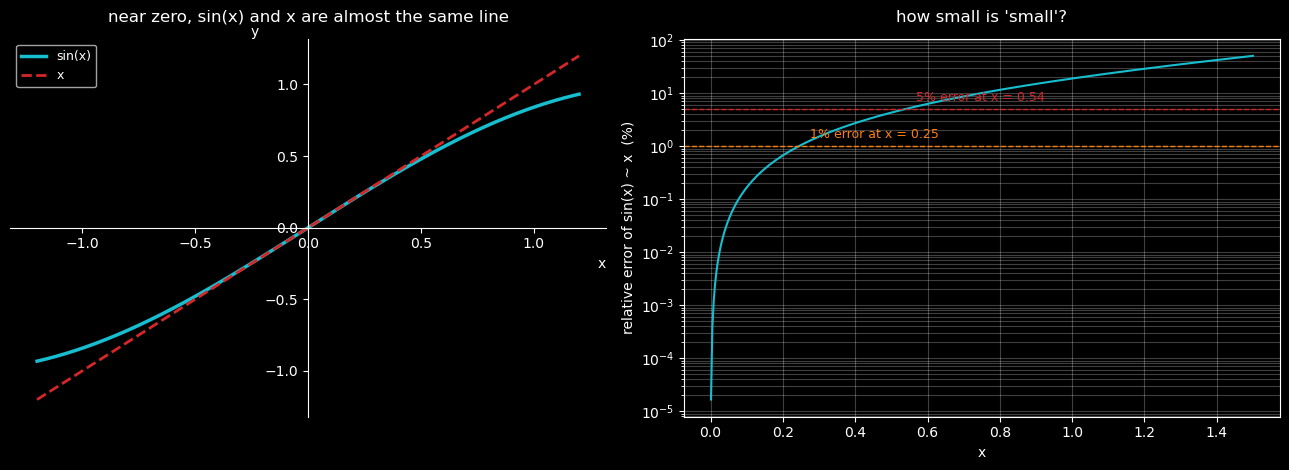

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

small = np.linspace(-1.2, 1.2, 400)
axes[0].plot(small, np.sin(small), color="tab:cyan", lw=2.5, label="sin(x)")
axes[0].plot(small, small, "--", color="tab:red", lw=2, label="x")
center_axes(axes[0])
axes[0].set_xlabel("x", loc="right"); axes[0].set_ylabel("y", loc="top", rotation=0)
axes[0].legend(fontsize=9)
axes[0].set_title("near zero, sin(x) and x are almost the same line", pad=12)

xr = np.linspace(1e-3, 1.5, 400)
axes[1].semilogy(xr, np.abs(xr - np.sin(xr)) / np.abs(np.sin(xr)) * 100, color="tab:cyan")
for tol, c in [(1, "tab:orange"), (5, "tab:red")]:
    axes[1].axhline(tol, color=c, ls="--", lw=1)
    cross = xr[np.argmin(np.abs(np.abs(xr - np.sin(xr))/np.abs(np.sin(xr))*100 - tol))]
    axes[1].annotate(f"{tol}% error at x = {cross:.2f}", (cross, tol),
                     textcoords="offset points", xytext=(8, 6), color=c, fontsize=9)
axes[1].set_xlabel("x"); axes[1].set_ylabel("relative error of sin(x) ~ x  (%)")
axes[1].grid(alpha=0.25, which="both")
axes[1].set_title("how small is 'small'?", pad=12)

plt.tight_layout()
plt.show()

## 4. Error: better with degree, worse with distance

Two things control the accuracy, and they pull in different directions.

**Degree.** More terms, smaller error — dramatically so. For $\sin$ the error falls faster than any
power of the degree.

**Distance from $a$.** The approximation is **local**. Far from the expansion point, even a
high-degree polynomial diverges wildly, because a polynomial must eventually run off to $\pm\infty$
while $\sin$ stays bounded.

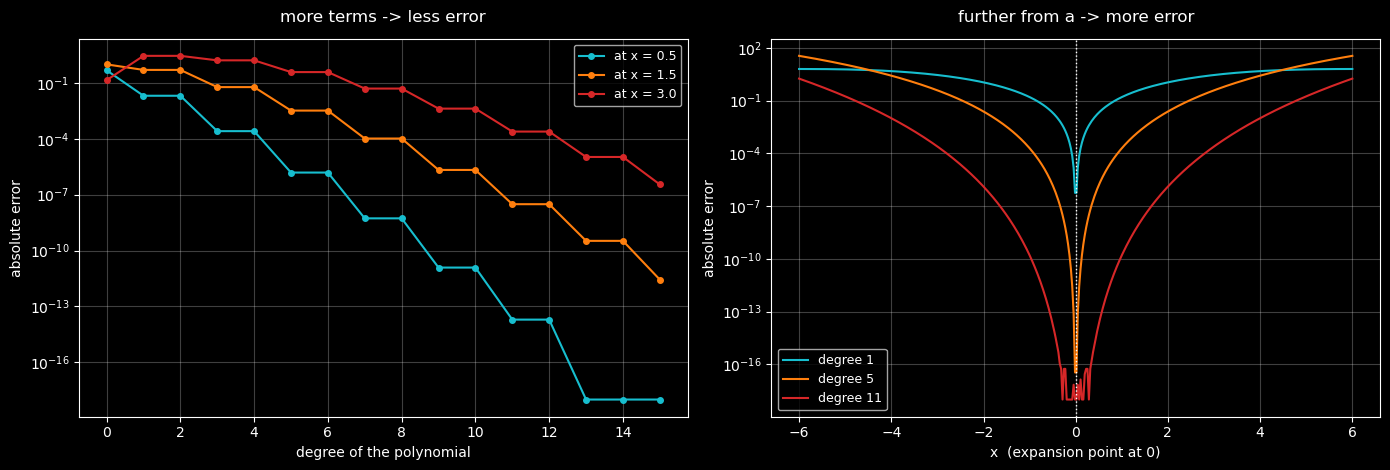

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# error vs degree, at a few fixed points
for xv, c in [(0.5, "tab:cyan"), (1.5, "tab:orange"), (3.0, "tab:red")]:
    errs = [abs(taylor(np.array([xv]), a, n)[0] - math.sin(xv)) for n in range(0, 16)]
    axes[0].semilogy(range(0, 16), np.maximum(errs, 1e-18), "o-", color=c,
                     markersize=4, label=f"at x = {xv}")
axes[0].set_xlabel("degree of the polynomial")
axes[0].set_ylabel("absolute error")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25, which="both")
axes[0].set_title("more terms -> less error", pad=12)

# error vs distance, at a few fixed degrees
dist = np.linspace(-6, 6, 400)
for n, c in [(1, "tab:cyan"), (5, "tab:orange"), (11, "tab:red")]:
    axes[1].semilogy(dist, np.maximum(np.abs(taylor(dist, a, n) - f(dist)), 1e-18),
                     color=c, label=f"degree {n}")
axes[1].axvline(0, color="white", ls=":", lw=1)
axes[1].set_xlabel("x  (expansion point at 0)")
axes[1].set_ylabel("absolute error")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.25, which="both")
axes[1].set_title("further from a -> more error", pad=12)

plt.tight_layout()
plt.show()

Read the right panel carefully: every curve has a **valley at $x = 0$**, the expansion point, and
climbs steeply on either side. That is what "local approximation" means — and it is why you re-expand
around a nearby point rather than pushing one expansion further.

## 5. Closing the loop: where §3.4's error rates came from

§3.4 measured that the forward difference has error $O(h)$ and the central difference $O(h^2)$, and
promised an explanation. Here it is — and it is three lines of Taylor.

Expand $f(x+h)$ about $x$:

$$f(x+h) = f(x) + f'(x)h + \frac{f''(x)}{2}h^2 + \cdots$$

**Forward difference.** Rearrange for $f'(x)$:

$$\frac{f(x+h) - f(x)}{h} = f'(x) + \frac{f''(x)}{2}h + \cdots$$

The leftover starts with a term proportional to $h$ — hence error $O(h)$.

**Central difference.** Expand $f(x-h)$ too and subtract. Every **even**-powered term cancels, because
it appears with the same sign in both:

$$\frac{f(x+h) - f(x-h)}{2h} = f'(x) + \frac{f'''(x)}{6}h^2 + \cdots$$

Now the leading leftover is proportional to $h^2$ — error $O(h^2)$. **That cancellation is the entire
reason central differences are more accurate**, and §3.4 could see it happening without being able to
say why.

In [8]:
# verify the leftover terms are the size Taylor predicts
g = np.sin
d1, d2, d3 = np.cos, lambda t: -np.sin(t), lambda t: -np.cos(t)
x0 = 0.7

print(f"{'h':>8} {'forward error':>16} {'predicted f\"/2 * h':>20} | "
      f"{'central error':>15} {'predicted f\"\"\"/6 * h^2':>22}")
print("-" * 92)
for h in [0.1, 0.05, 0.01, 0.005]:
    fwd_err = (g(x0+h) - g(x0))/h - d1(x0)
    cen_err = (g(x0+h) - g(x0-h))/(2*h) - d1(x0)
    print(f"{h:8.3f} {fwd_err:16.8f} {d2(x0)/2*h:20.8f} | "
          f"{cen_err:15.8f} {d3(x0)/6*h**2:22.8f}")
print("-" * 92)
print("\nThe measured errors match Taylor's predicted leading terms. Halving h halves the")
print("forward error and quarters the central one -- exactly the slopes 1 and 2 that")
print("section 3.4 measured off the log-log plot.")

       h    forward error   predicted f"/2 * h |   central error predicted f"""/6 * h^2
--------------------------------------------------------------------------------------------
   0.100      -0.03345815          -0.03221088 |     -0.00127410            -0.00127474
   0.050      -0.01642073          -0.01610544 |     -0.00031864            -0.00031868
   0.010      -0.00323381          -0.00322109 |     -0.00001275            -0.00001275
   0.005      -0.00161373          -0.00161054 |     -0.00000319            -0.00000319
--------------------------------------------------------------------------------------------

The measured errors match Taylor's predicted leading terms. Halving h halves the
forward error and quarters the central one -- exactly the slopes 1 and 2 that
section 3.4 measured off the log-log plot.


### 5.1 A closing warning: don't difference your way to high derivatives

One temptation this notebook deliberately avoids. You *could* get the derivatives for a Taylor
polynomial numerically, by applying a difference quotient repeatedly. It works for the first two or
three and then falls apart — each round of differencing divides by $h$ again and amplifies rounding
error, exactly the effect §3.4-1's error curve showed.

Worth measuring once, because the failure is quiet: the numbers still look plausible.

In [9]:
def nth_derivative_numeric(fn, x, k, h=1e-3):
    if k == 0:
        return fn(x)
    return (nth_derivative_numeric(fn, x+h, k-1, h)
            - nth_derivative_numeric(fn, x-h, k-1, h)) / (2*h)

print(f"{'k':>3} {'repeated differencing':>24} {'exact':>14} {'relative error':>16}")
print("-" * 62)
for k in range(6):
    approx = nth_derivative_numeric(np.sin, x0, k)
    exact_v = nth_derivative_exact(k, x0)
    rel = abs(approx - exact_v) / max(abs(exact_v), 1e-12)
    flag = "   <- degrading" if rel > 1e-3 else ""
    print(f"{k:>3} {approx:24.8f} {exact_v:14.8f} {rel:16.2e}{flag}")
print("-" * 62)
print("\nFine to order 3, visibly wrong by order 5 -- and it costs 2^k evaluations besides.")
print("This is why we used the closed-form derivatives throughout.")

  k    repeated differencing          exact   relative error
--------------------------------------------------------------
  0               0.64421769     0.64421769         0.00e+00
  1               0.76484206     0.76484219         1.67e-07
  2              -0.64421747    -0.64421769         3.33e-07
  3              -0.76484181    -0.76484219         4.87e-07
  4               0.64422773     0.64421769         1.56e-05
  5               0.77368667     0.76484219         1.16e-02   <- degrading
--------------------------------------------------------------

Fine to order 3, visibly wrong by order 5 -- and it costs 2^k evaluations besides.
This is why we used the closed-form derivatives throughout.


## 6. Summary

- A **Taylor polynomial** matches a function's value and derivatives at an expansion point $a$:
  $P_n(x) = \sum_{k=0}^{n} \frac{f^{(k)}(a)}{k!}(x-a)^k$.
- Accuracy **improves with degree** and **degrades with distance from $a$** — it is a *local*
  approximation.
- $\sin x \approx x$ is the first term of $\sin$'s expansion, accurate to about 1% out to $x \approx 0.24$.
- **§3.4's error rates come from here**: the forward difference leaves an $O(h)$ term, while the
  central difference cancels every even power and leaves $O(h^2)$.
- Getting high derivatives by repeated differencing degrades quickly — use closed forms.

---

**That closes Unit 3.** The arc was: approximation and error → limits → derivatives → numerical
derivatives → optimization → multivariable → gradient descent and your first ML model → integrals →
Taylor series. The last section paid back a debt from the fourth, which is a fair summary of how the
unit hangs together — nearly everything in it is some version of *replace the hard thing with a
simpler one, and measure the error*.

Next unit: probability and statistics, where the Monte Carlo methods pick up exactly where §3.8-5's
curse of dimensionality left off.